        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-03 05:25:44.807202: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751500544.828882  385745 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751500544.835415  385745 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 05:25:44.857500: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [ ]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    # '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from DWT1DFB import DWT1D, IDWT1D
# from DWT2DFB import DWT2D, IDWT2D


2025-02-16 01:13:42.313983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-16 01:13:42.342984: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-16 01:13:42.343053: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-16 01:13:42.362690: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-16 01:13:43.401498: W tensorflow/compiler/tf

TensorFlow version 2.16.2
Num GPUs Available:  3


2025-02-16 01:13:45.349774: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


In [6]:
from TFDWT.DWT1DFB import DWT1D, IDWT1D
import matplotlib.pyplot as plt


        MIMO batch

In [7]:
#%% Shift invariant Linear (m=1) Multiresolution Volterra Kernel
class LSVariantVolterra1Dmra(tf.keras.layers.Layer):
    """
        VolterraSysMRA: Multidimensional linear and nonlinear Volterra kernels in natural and biortogonal bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
        
    
        Shift variant Linear (m=1) Multiresolution Volterra Kernel
        Input: sequence x[n]
        Output: Shift variant linear monomial y1, i.e., m=1

    --@KKT, 16-Feb-2025"""
    
    def __init__(self, filters=1, Ny=16, wave='haar', **kwargs):
        super().__init__(**kwargs)
        # self.L = kernel_size
        self.wave = wave
        self.filters = filters
        self.Ny = Ny
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.L = self.N
        self.channels = input_shape[-1]
        kernel_shape = (self.Ny, self.L, input_shape[-1], self.filters)
        # kernel_shape = (self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel'
        )
        # n = tf.range(self.N)
        # self.row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        super().build(input_shape)
    

    def call(self, x):

        HT = self.__getH()
        print(HT.shape,'>')
      
        # hinit = DWT1D(wave)(tf.expand_dims(hshifted, axis=-1))
        # hinitT = tf.transpose(hinit, perm=[1,0,2])
 
        # H = DWT1D(wave)(hinitT)
        # HT = tf.transpose(H, perm=[1,0,2])
        # print(HT.shape, '\n', tf.squeeze(HT).numpy())   ## l-axis below --->l and ^v
        
        ## H[v,l] 
        α = DWT1D(self.wave, clean=False)(x)
        # print('α = ', α.shape)
        print('HT and α', HT.shape, α.shape)
        β = tf.einsum('bic,uico->buco',α,HT)
        β = tf.einsum('buco->buo',β)
        print('β', β.shape)

        # HTα = HT * α
        # print(HTα.shape, '\n', tf.squeeze(HTα).numpy())
        # beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
        
        # βT = tf.transpose(beta, perm=[1,0,2])
        # print('βT',tf.squeeze(βT).numpy())
        y = IDWT1D(self.wave, clean=False)(β)#
        # print('y',tf.squeeze(y).numpy())

        return y#, ynatural
    
    def __getH(self):
        # self.h1 = h

        paddings = [
           [0, self.N - self.L],  # Depth dimension
           [0, self.N - self.L],  # Depth dimension
           [0,0],
           [0,0]
        ]
        h_padded = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)
        # print(h_padded.shape,'>')
        hshifted = h_padded

        ## Creating x[n-k] for all n
        # hshifted = tf.gather(h_padded, self.row_indices, axis=0)
        # print(hshifted.shape,'>')
        # print(tf.concat([tf.transpose(DWT1D(self.wave)(tf.transpose(DWT1D(self.wave)(hshifted[...,i:i+1]), perm=[1,0,2])),perm=[1,0,2]) for i in range(self.channels)], axis=-1))

        HT = tf.stack([tf.concat([tf.transpose(DWT1D(self.wave)(tf.transpose(DWT1D(self.wave)(hshifted[...,i:i+1,j]), perm=[1,0,2])),perm=[1,0,2]) for i in range(self.channels)], axis=-1) for j in range(self.filters)], axis=-1)
        # print(HT.shape)
 
        return HT
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'Ny': self.Ny,
            'wavelet': self.wave,
            'filters': self.filters,
        })
        return config

lay = LSVariantVolterra1Dmra(filters=1, Ny=21)
# y = lay(xx)
# y = lay(tf.concat([xx,xx], axis=-1))
# y.shape

In [8]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
# x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)

        batch test

In [9]:
y = lay(tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0))
y.shape

(10, 8, 4, 1) >
HT and α (10, 8, 4, 1) (1, 16, 1)


2025-07-03 05:33:00.455748: W tensorflow/core/framework/op_kernel.cc:1841] OP_REQUIRES failed at einsum_op_impl.h:507 : INVALID_ARGUMENT: Expected dimension 16 at axis 1 of the input shaped [10,8,4,1] but got dimension 8
2025-07-03 05:33:00.455805: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Expected dimension 16 at axis 1 of the input shaped [10,8,4,1] but got dimension 8


InvalidArgumentError: Exception encountered when calling LSVariantVolterra1Dmra.call().

[1m{{function_node __wrapped__Einsum_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Expected dimension 16 at axis 1 of the input shaped [10,8,4,1] but got dimension 8 [Op:Einsum] name: [0m

Arguments received by LSVariantVolterra1Dmra.call():
  • x=tf.Tensor(shape=(1, 16, 1), dtype=float32)

In [34]:
h1 = lay.h1.numpy()
h1.shape, tf.squeeze(h1).numpy()

((32, 16, 1, 1),
 array([[ 4.42626029e-02,  1.18155852e-02, -1.63328722e-02,
         -4.21635807e-04, -3.04406546e-02, -6.87670931e-02,
         -1.05785728e-02,  4.13720235e-02,  5.74961677e-02,
          8.92978162e-03, -2.59106085e-02, -2.32913531e-02,
          2.48612463e-02,  2.61950195e-02,  4.69272882e-02,
         -2.95108296e-02],
        [-2.29052715e-02,  1.49197280e-02, -6.75672963e-02,
          5.48429415e-02, -3.28547098e-02, -6.80434033e-02,
          6.87383041e-02,  1.39429867e-02,  1.58343017e-02,
         -2.92363837e-02,  6.34748712e-02, -2.23096609e-02,
         -7.36298040e-02, -3.81310359e-02,  3.63000482e-03,
          4.45620492e-02],
        [ 7.23655596e-02, -4.94626313e-02, -3.04830149e-02,
         -2.34244503e-02, -4.07444164e-02, -1.84656195e-02,
         -1.48460902e-02, -3.30879092e-02, -3.49918902e-02,
         -4.78570759e-02, -2.14256980e-02, -4.38542217e-02,
         -6.56086579e-02, -3.42394002e-02, -8.64636153e-03,
         -6.54006451e-02],
  

In [6]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

3 Verify
---

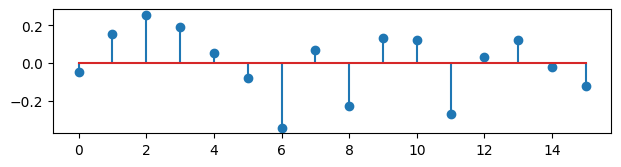

In [20]:
# plt.subplot(3,1,1), plt.stem(tf.squeeze(yhat).numpy())
plt.subplot(3,1,2), plt.stem(tf.squeeze(y).numpy())
# plt.subplot(3,1,3), plt.stem(tf.squeeze(y1n).numpy()), plt.title('natural')
plt.tight_layout()

In [ ]:
tf.reduce_sum(tf.square(tf.squeeze(yhat))).numpy(), tf.reduce_sum(tf.square(tf.squeeze(y1n))).numpy(), tf.reduce_sum(tf.square(tf.squeeze(y))).numpy()


(11.117986, 11.117989, 11.117987)

In [ ]:
break

2 BUILD
---


In [7]:
# x = [0,0,0,0,1,1,1,1]
wave = 'haar'
# wave = 'db2'
wave = 'db3'

## filter init
# h = tf.constant([1,2,3,5], dtype=tf.float32)
h = tf.squeeze(lay.h1.numpy())
# h = tf.constant([1,2,3,4], dtype=tf.float32)
# h = tf.constant([1,1,1,1], dtype=tf.float32)
# h = tf.constant([1,1], dtype=tf.float32)

# h = tf.constant([1.,5.], dtype=tf.float32)
# h = tf.constant([1,0,0,0], dtype=tf.float32)
## Matching filter size with input size with zero padding
x.shape, h.shape

(TensorShape([16]), TensorShape([4, 4]))

In [8]:
L = h.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = len(x)
paddings = [
           [0, Npoint - L],  # Depth dimension
        ]
h_padded = tf.pad(h, paddings, mode='CONSTANT', constant_values=0)
h_padded.shape


## Creating x[n-k] for all n
N = Npoint
n = tf.range(N)
row_indices = tf.math.mod(n[:, tf.newaxis]-n, N)
print(row_indices)
hshifted = tf.gather(h_padded, row_indices, axis=0)
print(x.shape, h_padded.shape, hshifted.shape), 
x, h_padded, hshifted

2025-02-16 01:14:17.352271: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: The first dimension of paddings must be the rank of inputs[1,2] [4,4]


InvalidArgumentError: {{function_node __wrapped__Pad_device_/job:localhost/replica:0/task:0/device:GPU:0}} The first dimension of paddings must be the rank of inputs[1,2] [4,4] [Op:Pad]

In [ ]:
hshifted[1,:] * x

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([-0.83988833,  0.10084581,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.38889506], dtype=float32)>

In [ ]:
# tf.reverse(tf.reverse(tf.math.mod(n[:, tf.newaxis] - n, N), axis=[0]), axis=[-1])

        True value

In [ ]:
res = []
for r in range(x.shape[0]):
    res.append(tf.reduce_sum(x * hshifted[r,:]))
y1n = tf.stack(res,axis=-1)
y1n
## OK

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([-0.7390425 , -1.1279376 , -0.7066408 , -0.70664084, -0.7066408 ,
       -0.70664084, -0.7066408 , -0.70664084, -0.7066408 , -0.80748665,
        0.03240171,  0.42129678,  0.        ,  0.        ,  0.        ,
        0.10084581], dtype=float32)>

In [ ]:
DWT1D(wave)(tf.expand_dims(tf.expand_dims(y1n, axis=0), axis=-1))

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[ 9.7963819e-03],
        [-7.0729442e-02],
        [-1.3500609e+00],
        [-9.9934101e-01],
        [-1.0028934e+00],
        [-1.0091374e+00],
        [-9.2861158e-01],
        [ 3.5427231e-01],
        [-2.6747227e-01],
        [ 2.9200450e-01],
        [-3.7137479e-02],
        [ 2.9802322e-08],
        [ 3.3548445e-02],
        [ 2.6747221e-01],
        [-2.9200453e-01],
        [ 3.5890974e-03]]], dtype=float32)>

---

In [ ]:
h.numpy(), hshifted.numpy(), hshifted[0,:].numpy(), hshifted[1,:].numpy(), x.numpy(), tf.reduce_sum(hshifted[1,:]*x).numpy() 
## OK  ## n-axis --->n

(array([ 0.10084581, -0.83988833, -0.38889506,  0.42129678], dtype=float32),
 array([[ 0.10084581,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.42129678, -0.38889506,
         -0.83988833],
        [-0.83988833,  0.10084581,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.42129678,
         -0.38889506],
        [-0.38889506, -0.83988833,  0.10084581,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.42129678],
        [ 0.42129678, -0.38889506, -0.83988833,  0.10084581,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.  

In [ ]:
# hshifted = tf.reverse(hshifted, axis=[1,0])
# hshifted

In [ ]:
tf.expand_dims(hshifted[0:1,:], axis=-1)

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[ 0.10084581],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.42129678],
        [-0.38889506],
        [-0.83988833]]], dtype=float32)>

In [ ]:
_ = tf.expand_dims(hshifted, axis=-1)
hinit = DWT1D(wave)(_)
# del _
print(tf.squeeze(hinit)) # l-axis below --->l  and n-axis ^

# OK
_ = _[1:2,...]
print(tf.squeeze(_).numpy())
tf.squeeze(DWT1D(wave)(_)).numpy() # 

tf.Tensor(
[[ 0.2658745  -0.760696    0.03354843  0.          0.          0.
   0.01484072 -0.05323817  0.5561186  -0.09907576  0.00355242  0.
   0.          0.         -0.14015302 -0.2281349 ]
 [ 0.32156357 -0.57350415 -0.19803447  0.          0.          0.
   0.         -0.04969547 -0.58928275  0.04863049 -0.02096976  0.
   0.          0.          0.          0.46931472]
 [-0.05323817  0.2658745  -0.760696    0.03354843  0.          0.
   0.          0.01484072 -0.22813493  0.5561186  -0.09907576  0.00355242
   0.          0.          0.         -0.14015302]
 [-0.04969547  0.3215636  -0.57350415 -0.19803447  0.          0.
   0.          0.          0.46931472 -0.5892828   0.04863049 -0.02096976
   0.          0.          0.          0.        ]
 [ 0.01484072 -0.05323817  0.2658745  -0.760696    0.03354843  0.
   0.          0.         -0.14015302 -0.2281349   0.5561186  -0.09907576
   0.00355242  0.          0.          0.        ]
 [ 0.         -0.04969547  0.3215636  -0.57350415 

array([ 0.32156357, -0.57350415, -0.19803447,  0.        ,  0.        ,
        0.        ,  0.        , -0.04969547, -0.58928275,  0.04863049,
       -0.02096976,  0.        ,  0.        ,  0.        ,  0.        ,
        0.46931472], dtype=float32)

In [ ]:
hinitT = tf.transpose(hinit, perm=[1,0,2])
print(hinit.shape, '\n', tf.squeeze(hinitT).numpy()) # n-axis below --->n  and ^l

(16, 16, 1) 
 [[ 0.2658745   0.32156357 -0.05323817 -0.04969547  0.01484072  0.
   0.          0.          0.          0.          0.          0.
   0.03354843 -0.19803447 -0.760696   -0.57350415]
 [-0.760696   -0.57350415  0.2658745   0.3215636  -0.05323817 -0.04969547
   0.01484072  0.          0.          0.          0.          0.
   0.          0.          0.03354843 -0.19803447]
 [ 0.03354843 -0.19803447 -0.760696   -0.57350415  0.2658745   0.3215636
  -0.05323817 -0.04969547  0.01484072  0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.03354843 -0.19803447 -0.760696   -0.57350415
   0.2658745   0.3215636  -0.05323817 -0.04969547  0.01484072  0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.03354843 -0.19803447
  -0.760696   -0.57350415  0.2658745   0.3215636  -0.05323817 -0.04969547
   0.01484072  0.          0.          0.        ]
 [ 0.          0.          0.   

In [ ]:
H = DWT1D(wave)(hinitT)

print(tf.squeeze(hinitT).numpy(), '\n\n', tf.squeeze(H).numpy())

##OK
print('\n\n',tf.squeeze(hinitT[0:1,...]).numpy(),'\n',tf.squeeze(DWT1D(wave)(hinitT[0:1,...])).numpy())
print('\n',tf.squeeze(hinitT[1:2,...]).numpy(),'\n',tf.squeeze(DWT1D(wave)(hinitT[1:2,...])).numpy())
## v-axis below --->v and ^l

[[ 0.2658745   0.32156357 -0.05323817 -0.04969547  0.01484072  0.
   0.          0.          0.          0.          0.          0.
   0.03354843 -0.19803447 -0.760696   -0.57350415]
 [-0.760696   -0.57350415  0.2658745   0.3215636  -0.05323817 -0.04969547
   0.01484072  0.          0.          0.          0.          0.
   0.          0.          0.03354843 -0.19803447]
 [ 0.03354843 -0.19803447 -0.760696   -0.57350415  0.2658745   0.3215636
  -0.05323817 -0.04969547  0.01484072  0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.03354843 -0.19803447 -0.760696   -0.57350415
   0.2658745   0.3215636  -0.05323817 -0.04969547  0.01484072  0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.03354843 -0.19803447
  -0.760696   -0.57350415  0.2658745   0.3215636  -0.05323817 -0.04969547
   0.01484072  0.          0.          0.        ]
 [ 0.          0.          0.          0.     

In [ ]:
HT = tf.transpose(H, perm=[1,0,2])
print(HT.shape, '\n', tf.squeeze(HT).numpy())   ## l-axis below --->l and ^v
# HT=H

(16, 16, 1) 
 [[-4.3241850e-01  8.6957410e-02 -9.8424405e-03  0.0000000e+00
   4.9370718e-03 -5.0984703e-02  3.2887393e-01 -6.3416362e-01
  -1.3614061e-01  1.4643058e-02 -1.0422105e-03  0.0000000e+00
  -4.6624780e-02  2.3833910e-01 -4.4678491e-01  3.7761042e-01]
 [-6.3416356e-01 -4.3241850e-01  8.6957410e-02 -9.8424405e-03
   0.0000000e+00  4.9370718e-03 -5.0984703e-02  3.2887393e-01
   3.7761039e-01 -1.3614063e-01  1.4643059e-02 -1.0422105e-03
   0.0000000e+00 -4.6624780e-02  2.3833907e-01 -4.4678494e-01]
 [ 3.2887393e-01 -6.3416362e-01 -4.3241850e-01  8.6957410e-02
  -9.8424405e-03  0.0000000e+00  4.9370718e-03 -5.0984703e-02
  -4.4678491e-01  3.7761042e-01 -1.3614063e-01  1.4643059e-02
  -1.0422105e-03  0.0000000e+00 -4.6624780e-02  2.3833910e-01]
 [-5.0984703e-02  3.2887396e-01 -6.3416362e-01 -4.3241850e-01
   8.6957410e-02 -9.8424405e-03  0.0000000e+00  4.9370718e-03
   2.3833907e-01 -4.4678491e-01  3.7761042e-01 -1.3614063e-01
   1.4643059e-02 -1.0422105e-03  0.0000000e+00 -4.662

        H[v,l] 

In [ ]:
_ = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
print('x:= ', _.shape, _[0,:,0].numpy())
α = DWT1D(wave)(_)

# α = IDWT1D(wave)(_)
# α = IDWT1D(wave)(α)

print('α:= ', α.shape, tf.squeeze(α).numpy())

x:=  (1, 16, 1) [1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1.]
α:=  (1, 16, 1) [-1.8522599e-01  1.0815430e+00  1.4142134e+00  1.4142135e+00
  1.3789872e+00  1.5994395e+00  3.3267054e-01  3.5226293e-02
  1.4343470e-02 -3.5226271e-02  2.9802322e-08  2.2351742e-08
  3.3267057e-01 -1.4343448e-02  3.5226293e-02 -3.3267054e-01]


In [ ]:
print('\n', HT[0,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[0,:,0] * α[0,:,0]).numpy())
print('\n', HT[1,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[1,:,0] * α[0,:,0]).numpy())
# print('\n', HT[2,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[2,:,0] * α[0,:,0]).numpy())
# print('\n', HT[3,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[3,:,0] * α[0,:,0]).numpy())
# 5.5 * 5.656854, 2.4999998*16.970562


 [-0.4324185   0.08695741 -0.00984244  0.          0.00493707 -0.0509847
  0.32887393 -0.6341636  -0.13614061  0.01464306 -0.00104221  0.
 -0.04662478  0.2383391  -0.4467849   0.37761042] 
 [-1.8522599e-01  1.0815430e+00  1.4142134e+00  1.4142135e+00
  1.3789872e+00  1.5994395e+00  3.3267054e-01  3.5226293e-02
  1.4343470e-02 -3.5226271e-02  2.9802322e-08  2.2351742e-08
  3.3267057e-01 -1.4343448e-02  3.5226293e-02 -3.3267054e-01] 
 [ 8.00951421e-02  9.40481722e-02 -1.39193116e-02  0.00000000e+00
  6.80815894e-03 -8.15469474e-02  1.09406665e-01 -2.23392341e-02
 -1.95272884e-03 -5.15820342e-04 -3.10602932e-11  0.00000000e+00
 -1.55106923e-02 -3.41860438e-03 -1.57385767e-02 -1.25619859e-01]

 [-0.63416356 -0.4324185   0.08695741 -0.00984244  0.          0.00493707
 -0.0509847   0.32887393  0.3776104  -0.13614063  0.01464306 -0.00104221
  0.         -0.04662478  0.23833907 -0.44678494] 
 [-1.8522599e-01  1.0815430e+00  1.4142134e+00  1.4142135e+00
  1.3789872e+00  1.5994395e+00  3.326705

In [ ]:
α[0,:,0]  * HT[0,:,0]

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([ 8.00951421e-02,  9.40481722e-02, -1.39193116e-02,  0.00000000e+00,
        6.80815894e-03, -8.15469474e-02,  1.09406665e-01, -2.23392341e-02,
       -1.95272884e-03, -5.15820342e-04, -3.10602932e-11,  0.00000000e+00,
       -1.55106923e-02, -3.41860438e-03, -1.57385767e-02, -1.25619859e-01],
      dtype=float32)>

        look

In [ ]:
HTα = HT * α
print(HTα.shape, '\n', tf.squeeze(HTα).numpy())

(16, 16, 1) 
 [[ 8.00951421e-02  9.40481722e-02 -1.39193116e-02  0.00000000e+00
   6.80815894e-03 -8.15469474e-02  1.09406665e-01 -2.23392341e-02
  -1.95272884e-03 -5.15820342e-04 -3.10602932e-11  0.00000000e+00
  -1.55106923e-02 -3.41860438e-03 -1.57385767e-02 -1.25619859e-01]
 [ 1.17463574e-01 -4.67679173e-01  1.22976333e-01 -1.39193125e-02
   0.00000000e+00  7.89654814e-03 -1.69611089e-02  1.15850093e-02
   5.41624334e-03  4.79572685e-03  4.36397168e-10 -2.32952199e-11
   0.00000000e+00  6.68760098e-04  8.39580223e-03  1.48632184e-01]
 [-6.09159991e-02 -6.85875177e-01 -6.11532032e-01  1.22976348e-01
  -1.35725997e-02  0.00000000e+00  1.64241833e-03 -1.79600203e-03
  -6.40844600e-03 -1.33018065e-02 -4.05730693e-09  3.27297883e-10
  -3.46712768e-04 -0.00000000e+00 -1.64241809e-03 -7.92883933e-02]
 [ 9.44369193e-03  3.55691314e-01 -8.96842718e-01 -6.11532092e-01
   1.19913153e-01 -1.57423876e-02  0.00000000e+00  1.73914741e-04
   3.41860927e-03  1.57385655e-02  1.12536673e-08 -3.042980

In [ ]:
93.33809   -15.909902  + 70.00357    -0.3535534
# 93.33809-42.4264+93.33809+8.485281
# 93.33809+35.001785-42.4264+15.909902

147.0782046

In [ ]:
beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
# beta = tf.expand_dims(tf.einsum('ijk->jk',HTα), axis=-1)
βT = tf.transpose(beta, perm=[1,0,2])
print(beta.shape, βT.shape, '\n', tf.squeeze(βT))

(16, 1, 1) (1, 16, 1) 
 tf.Tensor(
[ 9.7963512e-03 -7.0729420e-02 -1.3500608e+00 -9.9934089e-01
 -1.0028934e+00 -1.0091372e+00 -9.2861152e-01  3.5427237e-01
 -2.6747227e-01  2.9200447e-01 -3.7137613e-02 -6.5192580e-09
  3.3548281e-02  2.6747221e-01 -2.9200456e-01  3.5890639e-03], shape=(16,), dtype=float32)


In [ ]:
yhat = IDWT1D(wave)(βT)#
yhat

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[-7.3904252e-01],
        [-1.1279374e+00],
        [-7.0664072e-01],
        [-7.0664060e-01],
        [-7.0664084e-01],
        [-7.0664084e-01],
        [-7.0664072e-01],
        [-7.0664048e-01],
        [-7.0664078e-01],
        [-8.0748653e-01],
        [ 3.2401726e-02],
        [ 4.2129683e-01],
        [-8.3819032e-09],
        [-9.3132257e-09],
        [-3.5390258e-08],
        [ 1.0084584e-01]]], dtype=float32)>

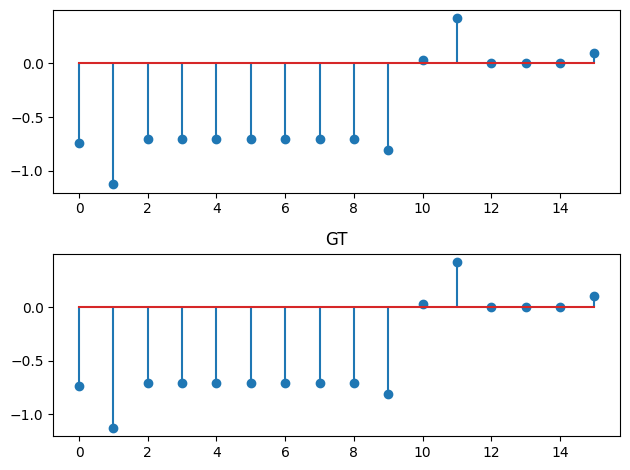

In [ ]:
plt.subplot(2,1,1), plt.stem(tf.squeeze(yhat).numpy())
plt.subplot(2,1,2), plt.stem(tf.squeeze(y1n).numpy()), plt.title('GT')
plt.tight_layout()


In [ ]:
tf.reduce_sum(tf.square(yhat)), tf.reduce_sum(tf.square(y1n)), 

(<tf.Tensor: shape=(), dtype=float32, numpy=6.1545596>,
 <tf.Tensor: shape=(), dtype=float32, numpy=6.154561>)